In [3]:
import os
os.chdir('cataract dataset/')
print(os.getcwd())

C:\Users\dffgg\Desktop\VGG19\cataract dataset


In [4]:
print(os.listdir())

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal', 'output.pdf']


In [5]:
dataset="cataract dataset"
img_size=224
x=[]
y=[]
normal_dir= "normal"
cataract_dir= "cataract"

In [6]:
import random
import cv2
import tensorflow as tf
import numpy as np 
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [11]:
normal_count = len(os.listdir(normal_dir))
cataract_count = len(os.listdir(cataract_dir))

print("Normal images:", normal_count)
print("Cataract images:", cataract_count)
# load normal images (0)
for img in os.listdir(normal_dir):
    img_path=os.path.join(normal_dir,img)
    img_arr=cv2.imread(img_path)
    img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
    img_arr=cv2.resize(img_arr,(img_size,img_size))
    x.append(img_arr)
    y.append(0)
# Load catarct images (1)
for img in os.listdir(cataract_dir):
    img_path=os.path.join(cataract_dir,img)
    img_arr=cv2.imread(img_path)
    img_arr=cv2.cvtColor(img_arr,cv2.COLOR_BGR2RGB)
    img_arr=cv2.resize(img_arr,(img_size,img_size))
    x.append(img_arr)
    y.append(1)
x=np.array(x)
y=np.array(y)
x=preprocess_input(x)
print(x.shape)
print(y.shape)

Normal images: 1074
Cataract images: 1038
(2112, 224, 224, 3)
(2112,)


In [12]:
# dataset splitting
x_train,x_temp, y_train,y_temp= train_test_split(x,y, test_size=0.4, random_state=SEED, stratify=y)
x_test,x_val, y_test,y_val= train_test_split(x_temp,y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)
print(x_train.shape)
print(x_test.shape)
print(x_val.shape)
train_gen= ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,zoom_range=0.2, horizontal_flip=True)
val_gen= ImageDataGenerator()

(1267, 224, 224, 3)
(422, 224, 224, 3)
(423, 224, 224, 3)


In [13]:
class_weights= class_weight.compute_class_weight("balanced", classes=np.unique(y_train),y=y_train)
class_weights= dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.9836956521739131), 1: np.float64(1.0168539325842696)}


In [14]:
base_model= VGG19(weights="imagenet", include_top= False, input_shape=(img_size,img_size,3))
base_model.trainable=False
x= base_model.output
x= GlobalAveragePooling2D()(x)
x= Dense(128,activation="relu")(x)
x= Dropout(0.5)(x)
output= Dense(1,activation="sigmoid")(x)
model= Model(inputs=base_model.input, outputs=output)
model.compile(optimizer= Adam(learning_rate=1e-4),loss="binary_crossentropy", metrics=["accuracy"])
model.summary()
hisotry=model.fit(train_gen.flow(x_train,y_train,batch_size=32), epochs=25, validation_data=val_gen.flow(x_val,y_val), class_weight=class_weights)
# fine tuning
base_model.trainable= True
for layer in base_model.layers[:-50]:
    layer.trainable=False
model.compile(optimizer= Adam(learning_rate=1e-4),loss="binary_crossentropy", metrics=["accuracy"])
hisotry=model.fit(train_gen.flow(x_train,y_train,batch_size=32), epochs=15, validation_data=val_gen.flow(x_val,y_val), class_weight=class_weights)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,090,177 (76.64 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.5462 - loss: 1.5786 - val_accuracy: 0.8416 - val_loss: 0.4023
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 180s 5s/step - accuracy: 0.7553 - loss: 0.7664 - val_accuracy: 0.9173 - val_loss: 0.2519
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.8114 - loss: 0.5441 - val_accuracy: 0.9338 - val_loss: 0.2546
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 181s 5s/step - accuracy: 0.8635 - loss: 0.4370 - val_accuracy: 0.9385 - val_loss: 0.2193
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 180s 5s/step - accuracy: 0.8824 - loss: 0.3588 - val_accuracy: 0.9456 - val_loss: 0.2256
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.8753 - loss: 0.3538 - val_accuracy: 0.9456 - val_loss: 0.2042
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 183s 5s/step - accuracy: 0.8856 - loss: 0.3251 - val_accuracy: 0.9480 - val_loss: 0.1960
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 180s 5s/step - accuracy: 0.9045 - loss: 0.2861 - val_accuracy: 0.9480 - v

In [15]:
loss, accuracy= model.evaluate (x_test,y_test)
print("accuracy:", accuracy)
print("loss:", loss)
y_pred=model.predict(x_test)
y_pred=np.round(y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.9668 - loss: 0.0958
accuracy: 0.9668246507644653
loss: 0.09575245529413223
14/14 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       215
           1       0.98      0.95      0.97       207

    accuracy                           0.97       422
   macro avg       0.97      0.97      0.97       422
weighted avg       0.97      0.97      0.97       422

[[211   4]
 [ 10 197]]


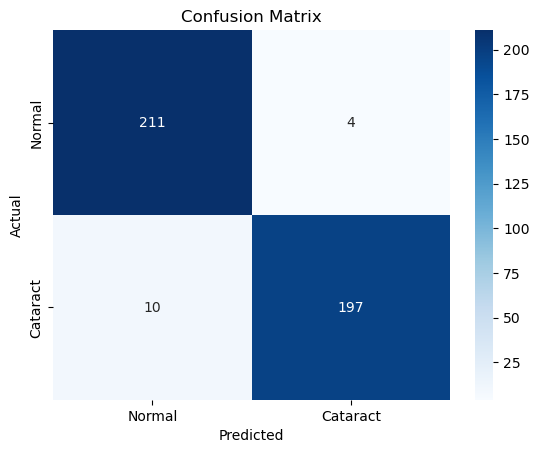

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, np.round(y_pred)), annot=True, fmt="d", cmap="Blues",
           xticklabels=["Normal","Cataract"],
           yticklabels=["Normal","Cataract"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('Confusion Matrix')
plt.savefig("output.pdf")
plt.show()

In [17]:
import os
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
folder_path=r"C:\Users\dffgg\Desktop\VGG19\test_img"
for fname in os.listdir(folder_path):
    if fname.lower().endswith((".png",".jpg",".jpeg")):
        image_path=os.path.join(folder_path,fname)
        img=load_img(image_path,target_size=(224,224))
        img=img_to_array(img)
        img=np.expand_dims(img,axis=0)
        img=preprocess_input(img)
        prob=model.predict(img)[0][0]
        label="cataract" if prob>=0.5 else "normal"
        print(f"{fname}:{label} (prob={prob:.2f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
cataract fundus img.png:cataract (prob=0.94)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
cataract fundus img2.png:cataract (prob=0.92)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
cataract fundus img3.png:cataract (prob=0.96)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
cataract fundus img4.png:cataract (prob=0.98)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
Normal fundus img 2.png:normal (prob=0.01)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Normal fundus img 3.png:normal (prob=0.02)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
Normal fundus img.png:normal (prob=0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
Normal fundus img4.png:normal (prob=0.00)


14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step


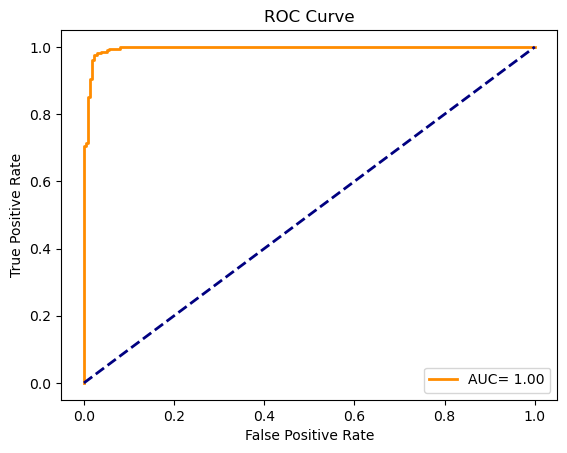

AUC: 0.99532636782384


In [18]:
from sklearn.metrics import roc_curve, auc
y_pred_prob= model.predict(x_test)
fpr,tpr,thresholds= roc_curve(y_test, y_pred_prob)
roc_auc= auc(fpr,tpr)
plt.figure()
plt.plot(fpr,tpr,color="darkorange", lw=2, label="AUC= %0.2f" % roc_auc)
plt.plot([0,1],[0,1],color="navy", lw=2, linestyle= "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc= "lower right")
plt.show()
print("AUC:", roc_auc)

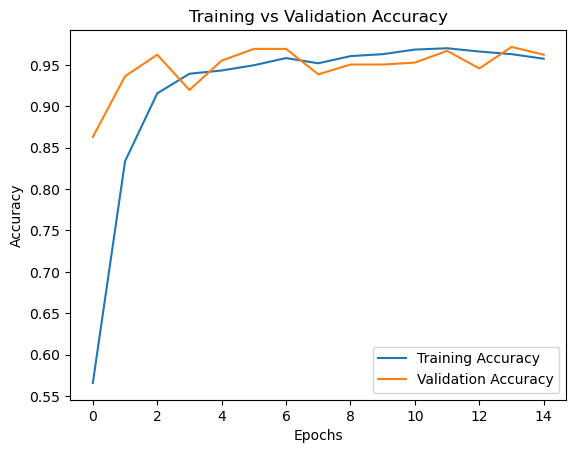

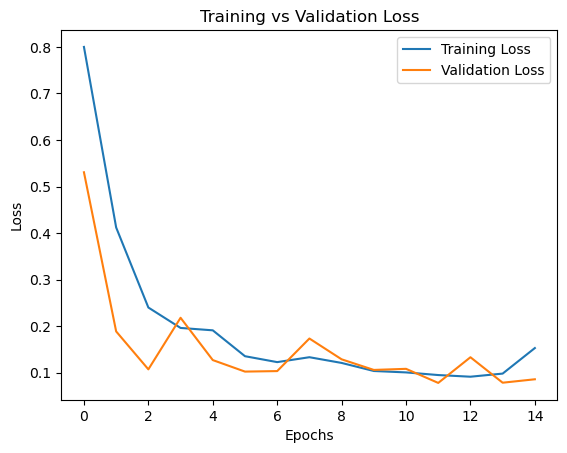

In [21]:
# accuracy plot
plt.figure()
plt.plot(hisotry.history["accuracy"], label= "Training Accuracy")
plt.plot(hisotry.history["val_accuracy"], label= "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# loss plot
plt.figure()
plt.plot(hisotry.history["loss"], label= "Training Loss")
plt.plot(hisotry.history["val_loss"], label= "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [5]:
!pip install transformers
!pip install --upgrade transformers

   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ---------------------------------------  10.2/10.2 MB 56.7 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 41.7 MB/s  0:00:00
   ---------------------------------------- 0.0/625.2 kB ? eta -:--:--
   ---------------------------------------- 625.2/625.2 kB 61.6 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 3.7/3.7 MB 97.3 MB/s  0:00:00

  Attempting uninstall: regex

    Found existing installation: regex 2025.9.1

    Uninstalling regex-2025.9.1:

      Successfully uninstalled regex-2025.9.1

   ---------------------------------------- 0/4 [regex]
   ---------------------------------------- 0/4 [regex]
   ---------------------------------------- 0/4 [regex]
   ---------------------------------------- 0/4 [regex]
   ---------------------------------------- 0/4 [regex]
   --------------------------------------

  You can safely remove it manually.


In [1]:
import tensorflow as tf
import numpy as np
import os
from transformers import ViTImageProcessor, TFViTForImageClassification
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
data_dir = "cataract dataset"

images = []
labels = []

for label, folder in enumerate(["normal", "cataract"]):
    path = os.path.join(data_dir, folder)
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        images.append(img_path)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)
# 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.4, random_state=42, stratify=labels)

# split temp into val + test (20/20)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(x_train.shape)
print(x_test.shape)
print(x_val.shape)

`ViTImageProcessor` requires torchvision (not installed); falling back to `ViTImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `ViTImageProcessorPil` directly to silence this warning.


ImportError: cannot import name 'TFViTForImageClassification' from 'transformers' (C:\Users\dffgg\anaconda3\Lib\site-packages\transformers\__init__.py)